In [6]:
#importing several python liberaries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [7]:
# load data
df = pd.read_csv("data/data.csv")

In [ ]:
# preview data (content of data)
df.head()

,Age,Gender,Protein1,Protein2,Protein3,Protein4,Tumour_Stage,Histology,ER status,PR status,HER2 status,Surgery_type,Date_of_Surgery,Date_of_Last_Visit,Patient_Status
0,42,FEMALE,0.95256,2.15000,0.007972,-0.048340,II,Infiltrating Ductal Carcinoma,Positive,Positive,Negative,Other,20-May-18,26-Aug-18,Alive
1,54,FEMALE,0.00000,1.38020,-0.498030,-0.507320,II,Infiltrating Ductal Carcinoma,Positive,Positive,Negative,Other,26-Apr-18,25-Jan-19,Dead
2,63,FEMALE,-0.52303,1.76400,-0.370190,0.010815,II,Infiltrating Ductal Carcinoma,Positive,Positive,Negative,Lumpectomy,24-Aug-18,08-Apr-20,Alive
3,78,FEMALE,-0.87618,0.12943,-0.370380,0.132190,I,Infiltrating Ductal Carcinoma,Positive,Positive,Negative,Other,16-Nov-18,28-Jul-20,Alive
4,42,FEMALE,0.22611,1.74910,-0.543970,-0.390210,II,Infiltrating Ductal Carcinoma,Positive,Positive,Positive,Lumpectomy,12-Dec-18,05-Jan-19,Alive


In [9]:
# technical structure of data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 334 entries, 0 to 333
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 334 non-null    int64  
 1   Gender              334 non-null    object 
 2   Protein1            334 non-null    float64
 3   Protein2            334 non-null    float64
 4   Protein3            334 non-null    float64
 5   Protein4            334 non-null    float64
 6   Tumour_Stage        334 non-null    object 
 7   Histology           334 non-null    object 
 8   ER status           334 non-null    object 
 9   PR status           334 non-null    object 
 10  HER2 status         334 non-null    object 
 11  Surgery_type        334 non-null    object 
 12  Date_of_Surgery     334 non-null    object 
 13  Date_of_Last_Visit  317 non-null    object 
 14  Patient_Status      321 non-null    object 
dtypes: float64(4), int64(1), object(10)
memory usage: 39.3+ K

In [11]:
# summary
df.describe()

,Age,Protein1,Protein2,Protein3,Protein4
count,334.000000,334.000000,334.000000,334.000000,334.000000
mean,58.886228,-0.029991,0.946896,-0.090204,0.009819
std,12.961212,0.563588,0.911637,0.585175,0.629055
min,29.000000,-2.340900,-0.978730,-1.627400,-2.025500
25%,49.000000,-0.358888,0.362173,-0.513748,-0.377090
50%,58.000000,0.006129,0.992805,-0.173180,0.041768
75%,68.000000,0.343598,1.627900,0.278353,0.425630
max,90.000000,1.593600,3.402200,2.193400,1.629900


In [12]:
# missing value treatment (data cleaning)
df.isnull().sum()

Age                    0
Gender                 0
Protein1               0
Protein2               0
Protein3               0
Protein4               0
Tumour_Stage           0
Histology              0
ER status              0
PR status              0
HER2 status            0
Surgery_type           0
Date_of_Surgery        0
Date_of_Last_Visit    17
Patient_Status        13
dtype: int64

In [22]:
cols=[ 'Protein1', 'Protein2', 'Protein3', 'Protein4' ]

In [23]:
df[cols]=df[cols].replace(0,np.NAN)

In [24]:
df.isnull().sum()

Age                    0
Gender                 0
Protein1               2
Protein2               0
Protein3               0
Protein4               1
Tumour_Stage           0
Histology              0
ER status              0
PR status              0
HER2 status            0
Surgery_type           0
Date_of_Surgery        0
Date_of_Last_Visit    17
Patient_Status        13
dtype: int64

In [25]:
df[cols]=df[cols].fillna(df[cols].mean())
df.isnull().sum()

Age                    0
Gender                 0
Protein1               0
Protein2               0
Protein3               0
Protein4               0
Tumour_Stage           0
Histology              0
ER status              0
PR status              0
HER2 status            0
Surgery_type           0
Date_of_Surgery        0
Date_of_Last_Visit    17
Patient_Status        13
dtype: int64

In [27]:
df_num=df.select_dtypes(include=np.number)
df.columns

Index(['Age', 'Gender', 'Protein1', 'Protein2', 'Protein3', 'Protein4',
       'Tumour_Stage', 'Histology', 'ER status', 'PR status', 'HER2 status',
       'Surgery_type', 'Date_of_Surgery', 'Date_of_Last_Visit',
       'Patient_Status'],
      dtype='object')

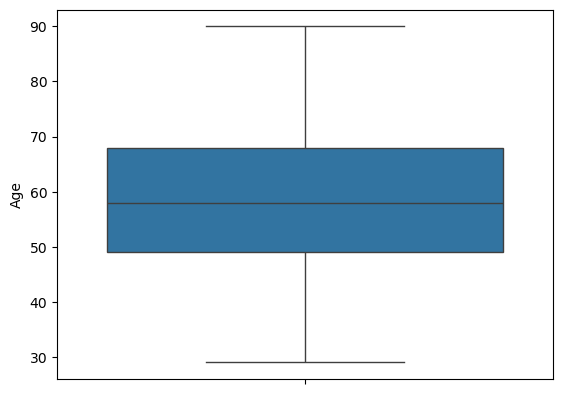

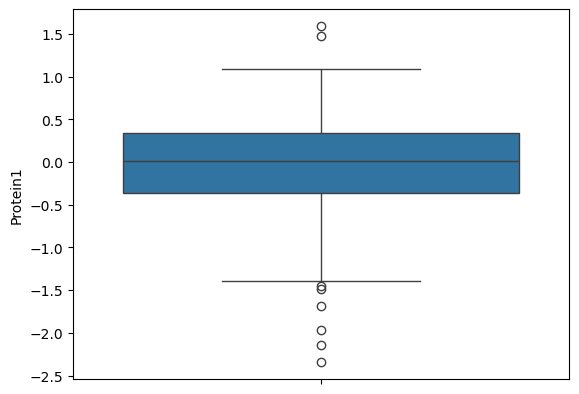

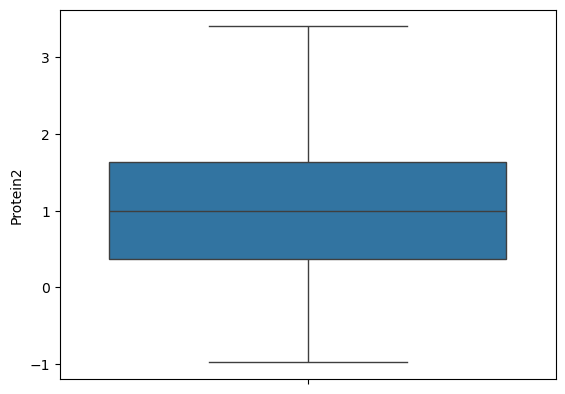

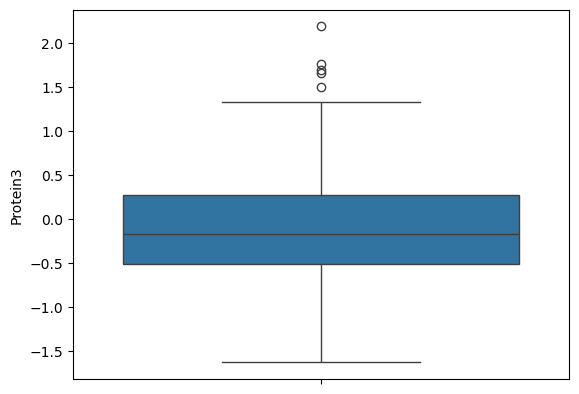

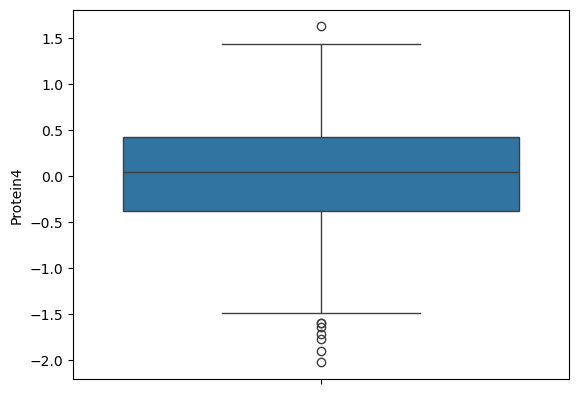

In [28]:
# outlier detection
for i in df_num.columns:
    sns.boxplot(df_num[i])
    plt.show()

In [29]:
# outlier handling
for i in df_num.columns:
    q1=df_num[i].quantile(0.25)
    q3=df_num[i].quantile(0.75)
    iqr=q3-q1
    ub=q3+1.5*iqr
    lb=q1-1.5*iqr
    df_num[i]=np.where(df_num[i]<lb,lb,df_num[i])
    df_num[i]=np.where(df_num[i]>ub,ub,df_num[i])

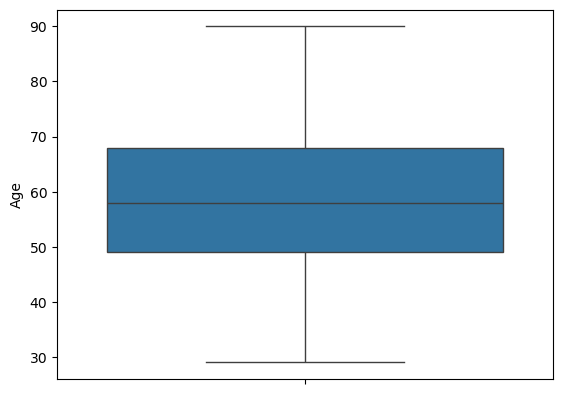

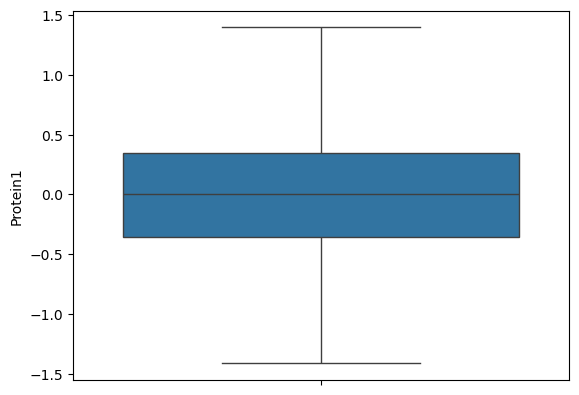

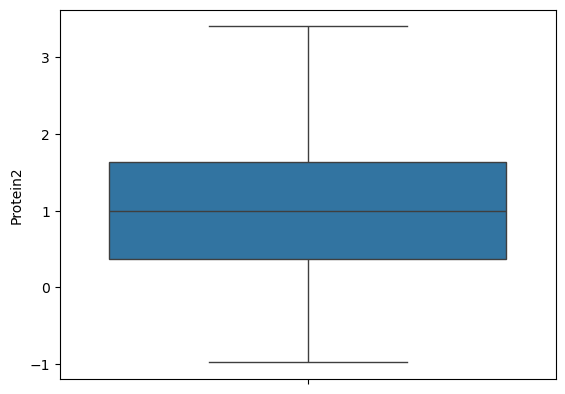

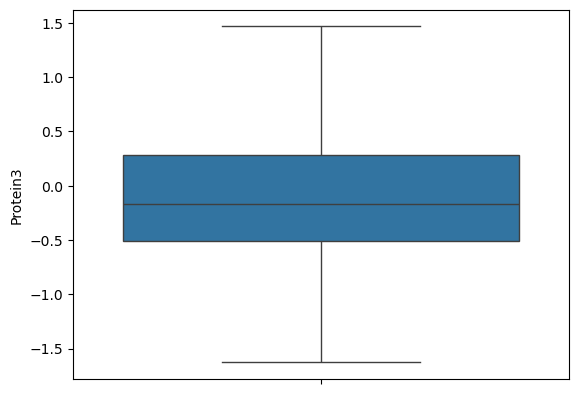

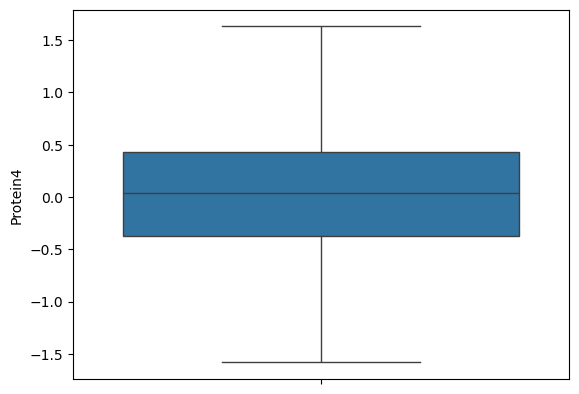

In [30]:
for i in df_num.columns:
    sns.boxplot(df_num[i])
    plt.show()

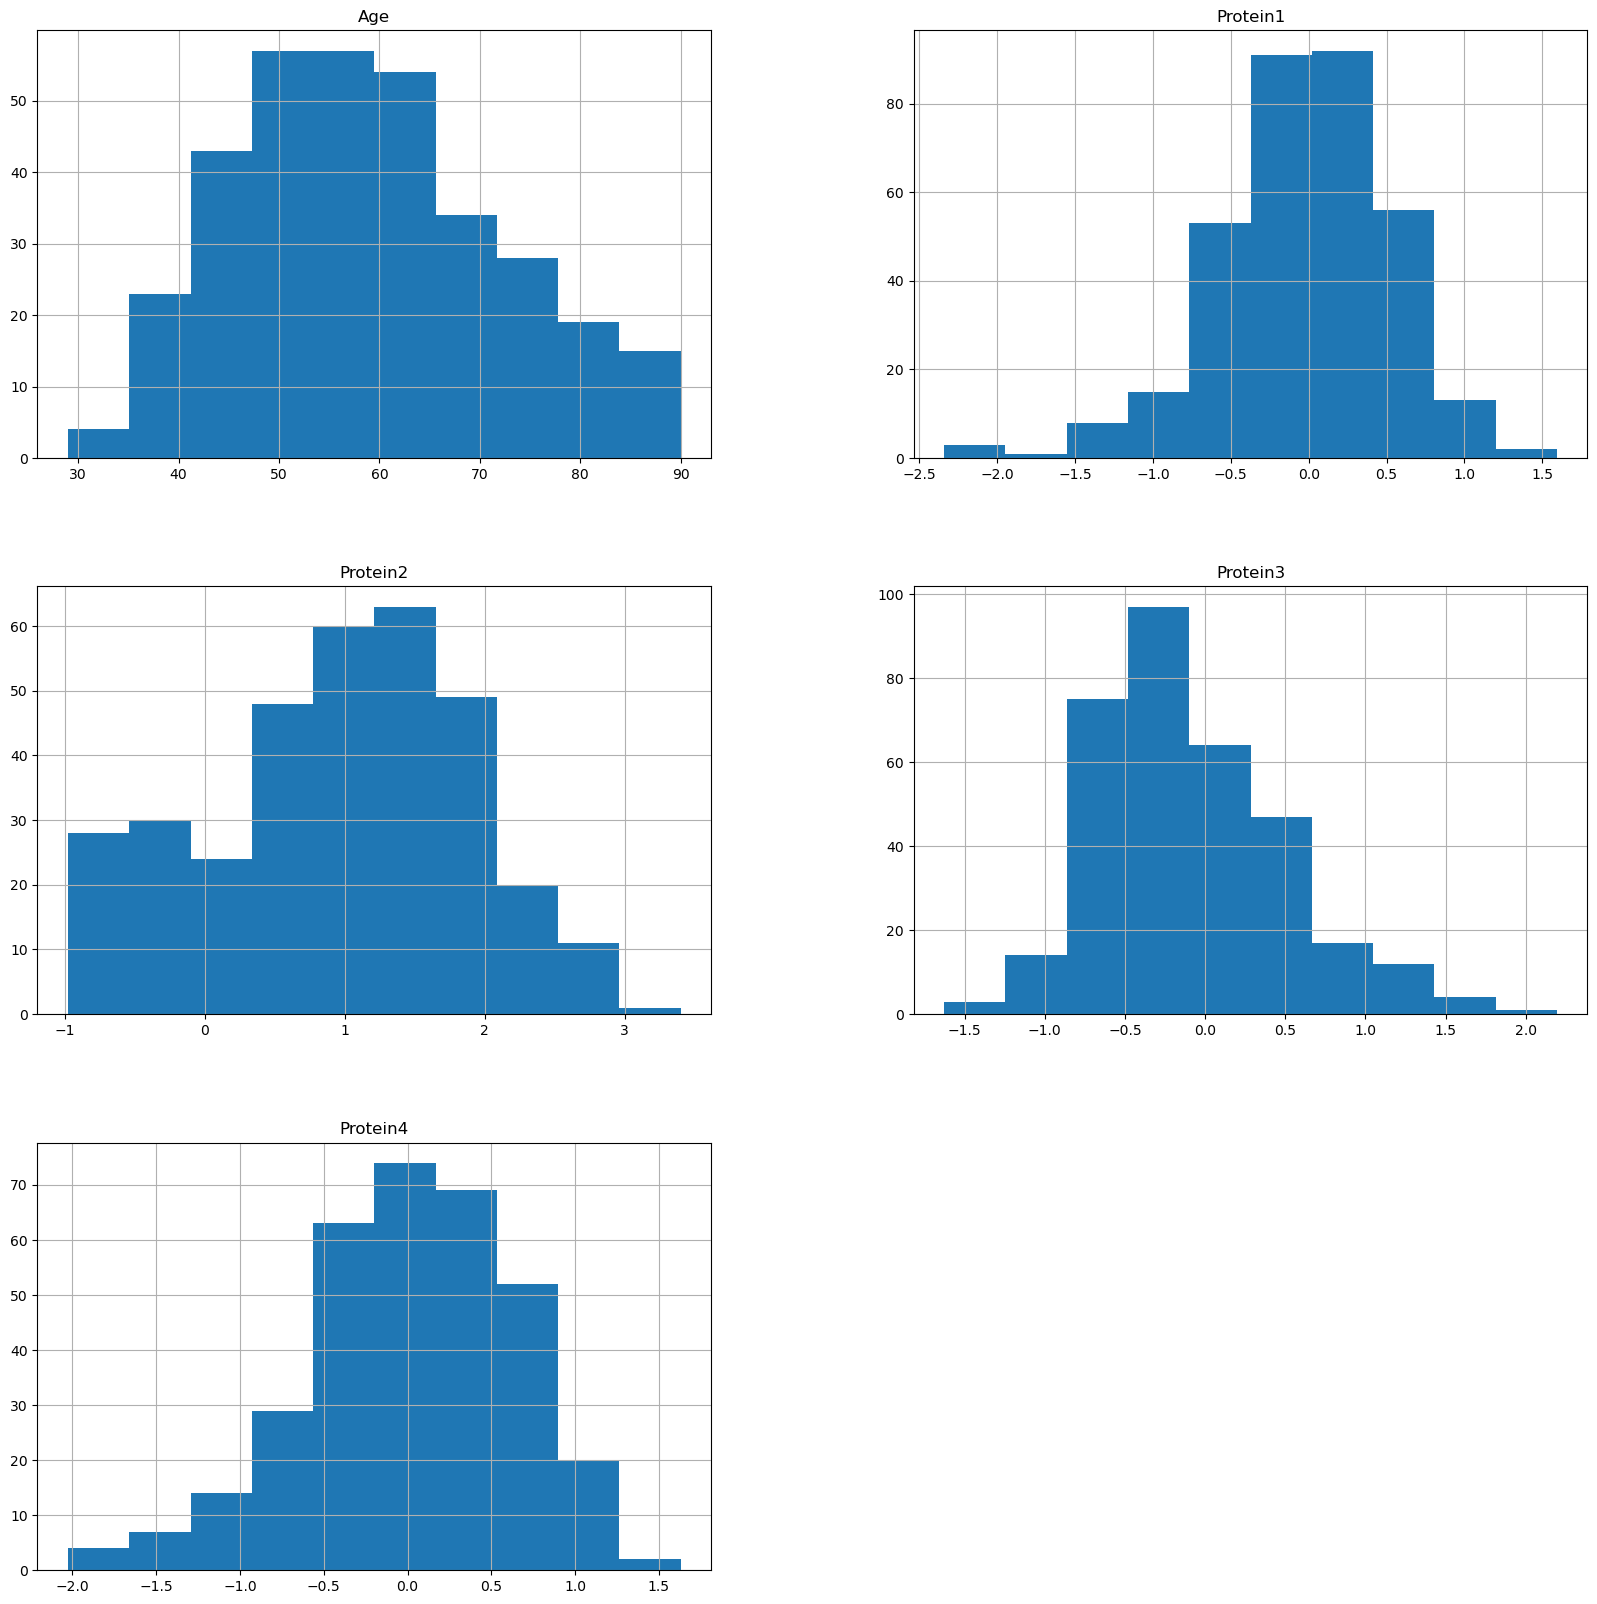

In [31]:
# distribution of data (histogram)
hplot=df.hist(figsize=(20,20))

In [32]:
# target value
df.Patient_Status.value_counts()

Patient_Status
Alive    255
Dead      66
Name: count, dtype: int64

In [33]:
# change column name if different
y = df['Patient_Status'].map({'Alive':1,'Dead':0})

# drop target column from features
x = df.drop('Patient_Status', axis=1)

<Axes: xlabel='Patient_Status'>

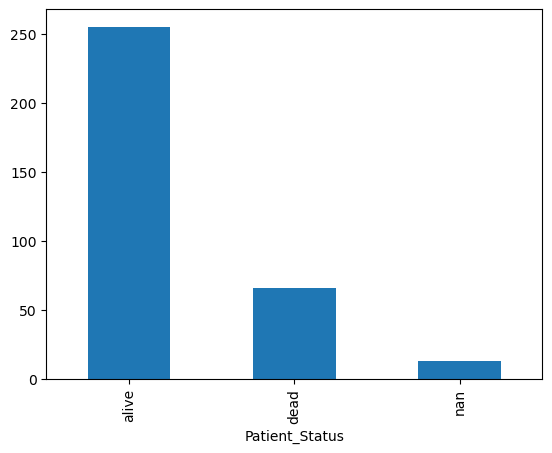

In [106]:
df.Patient_Status.value_counts().plot(kind='bar', )

In [35]:
# convert categorical --> numerical
x = pd.get_dummies(x,drop_first=True)

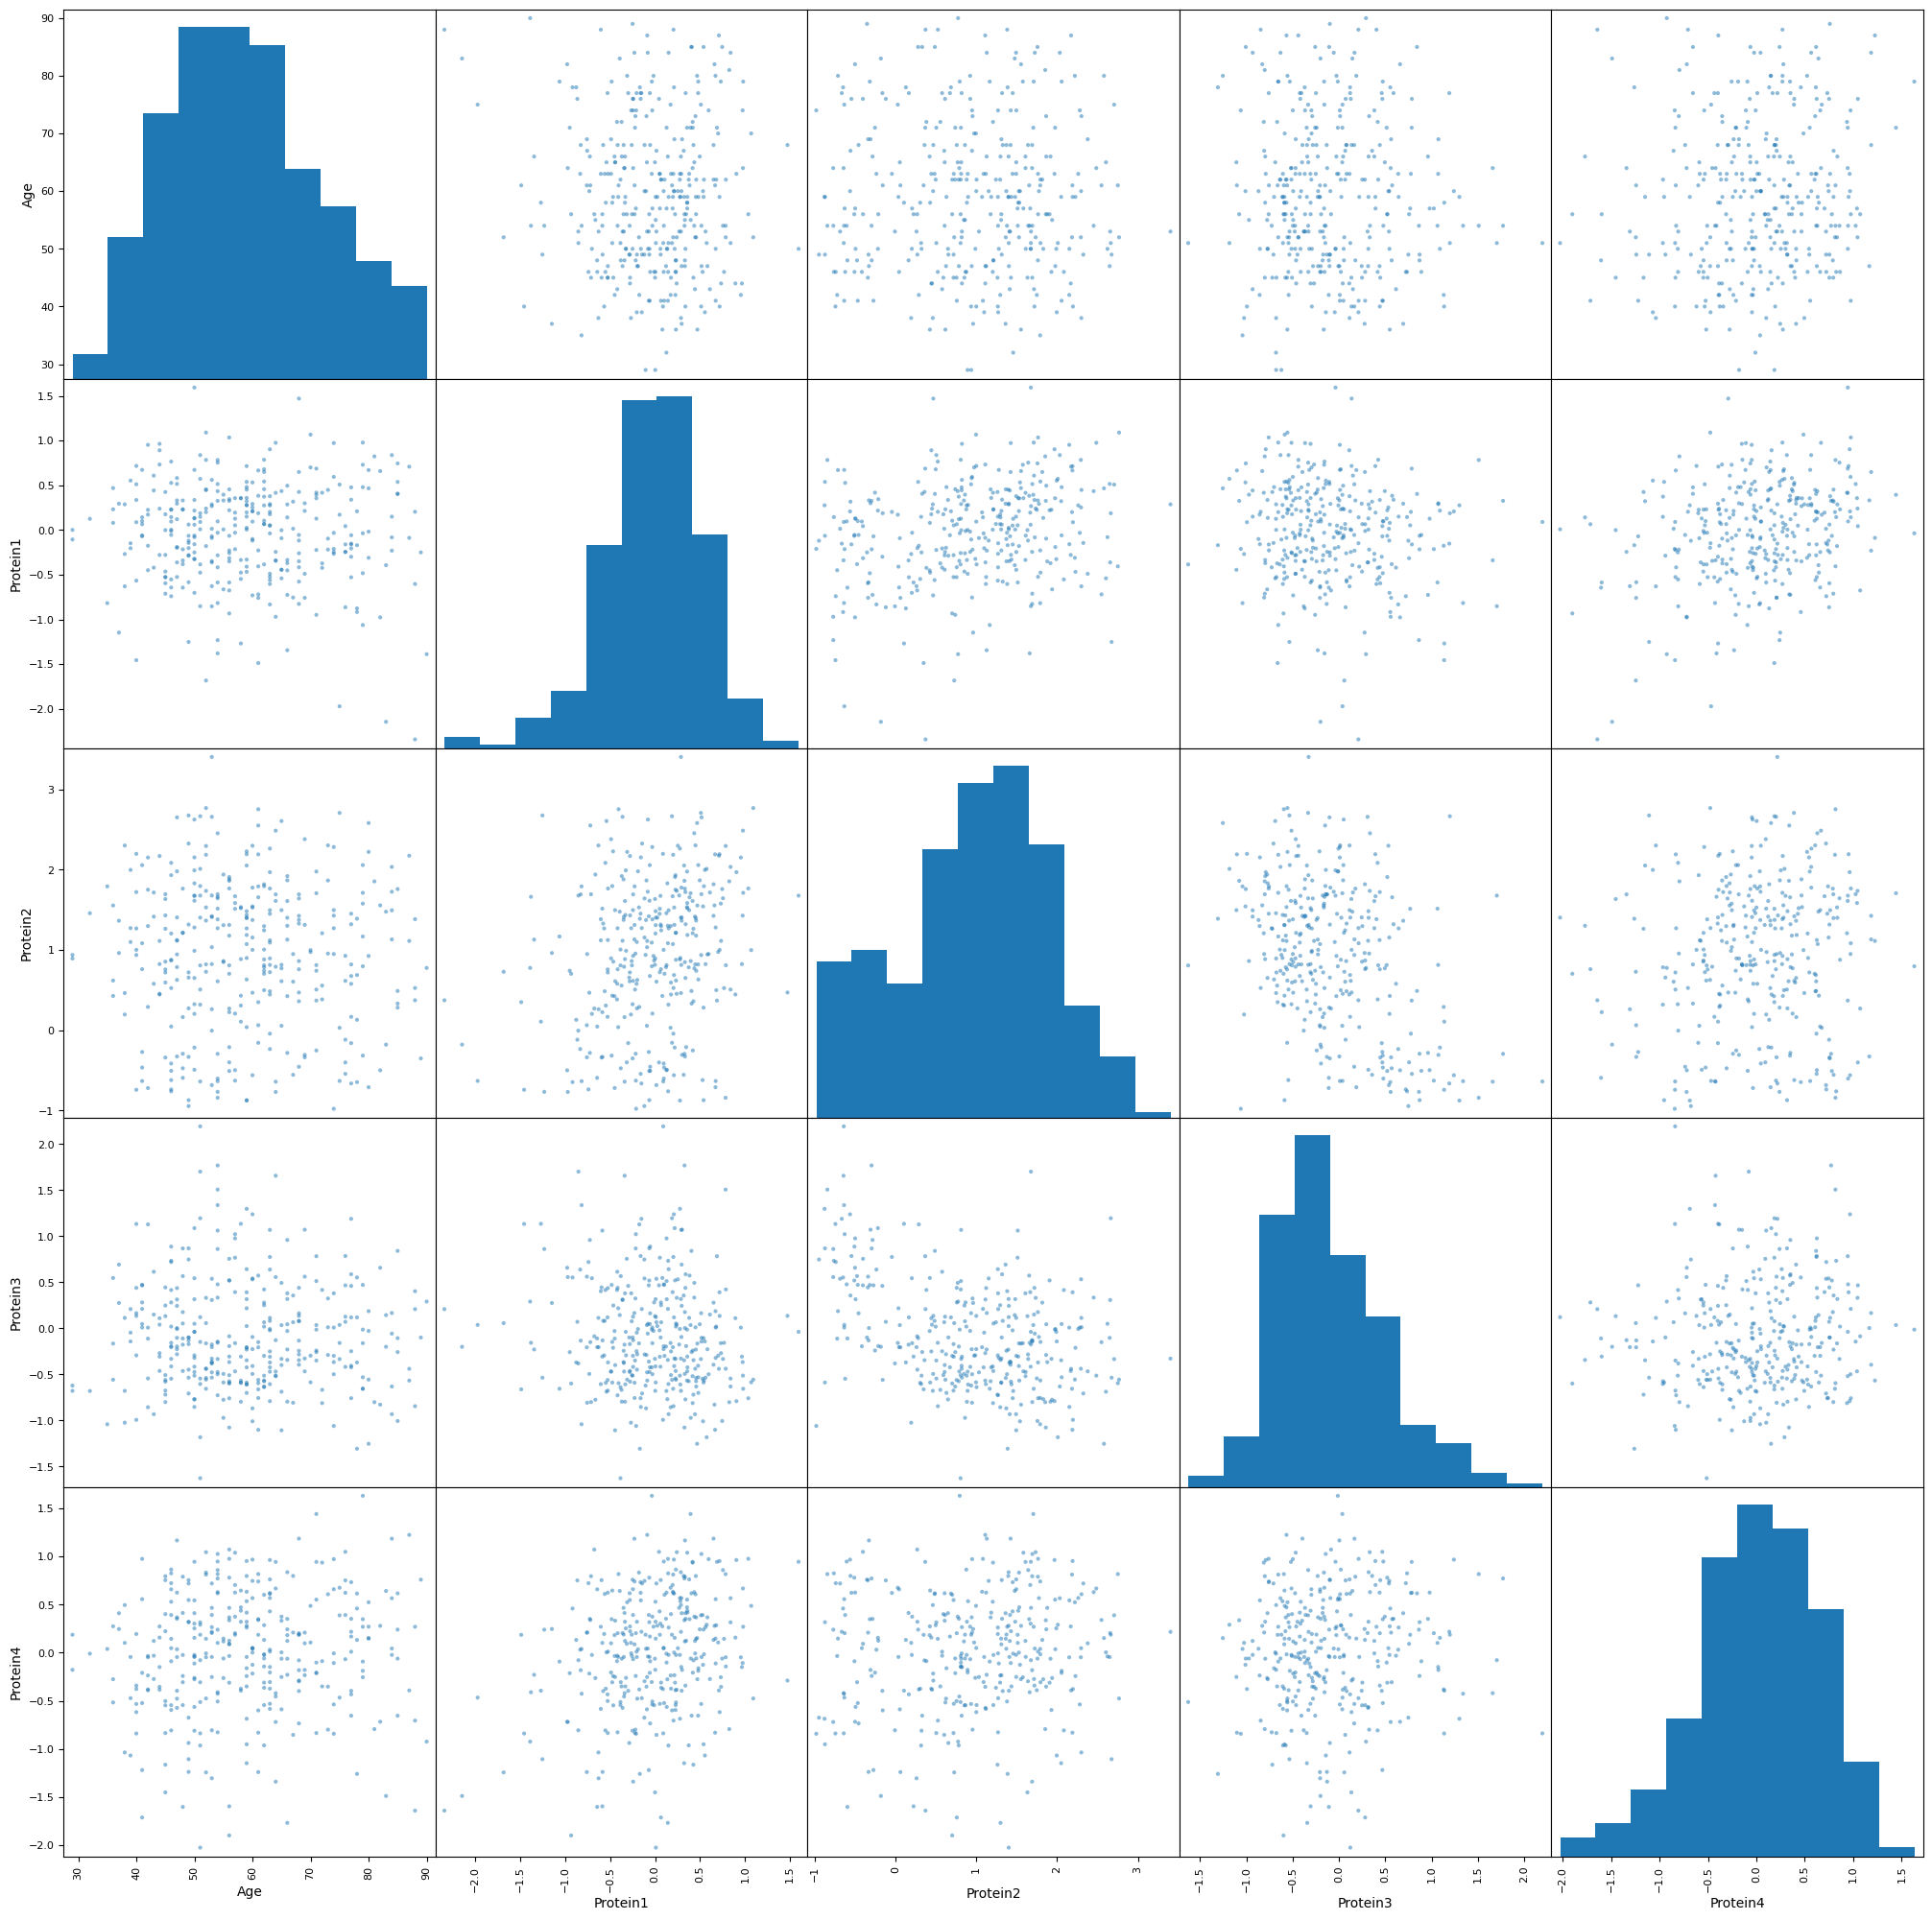

In [36]:
# scatter matrix
from pandas.plotting import scatter_matrix
p = scatter_matrix(df,figsize=(25,25))

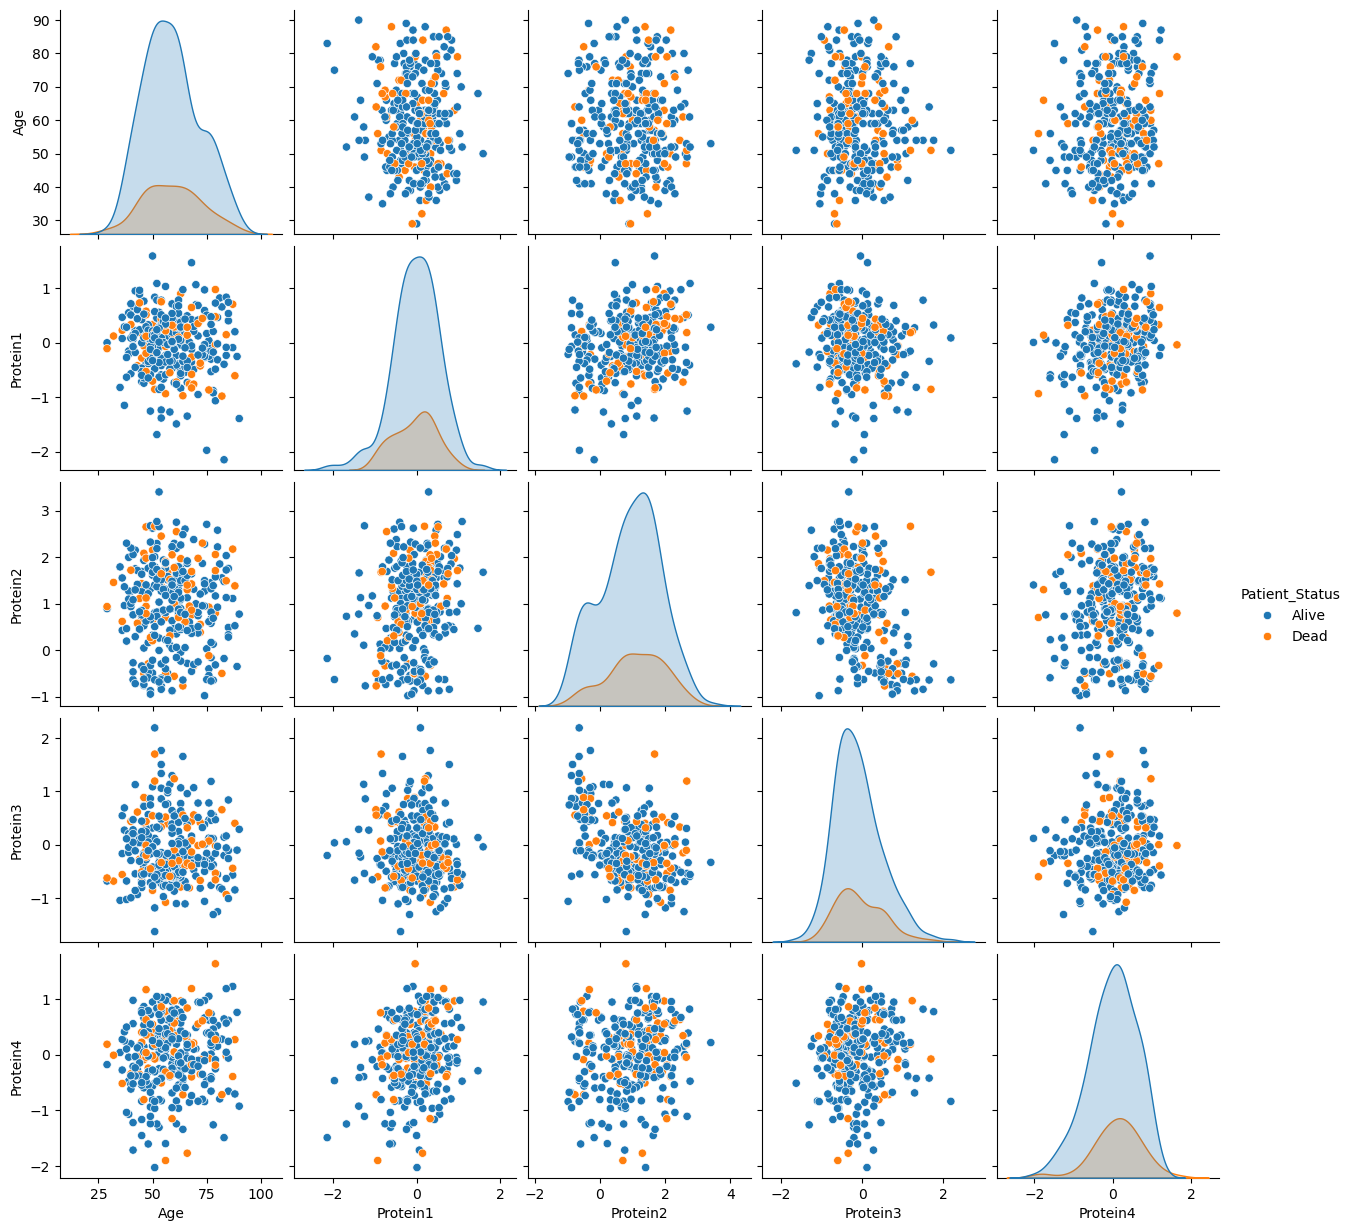

In [38]:
# seaborn pairplot
p = sns.pairplot(df,hue='Patient_Status')

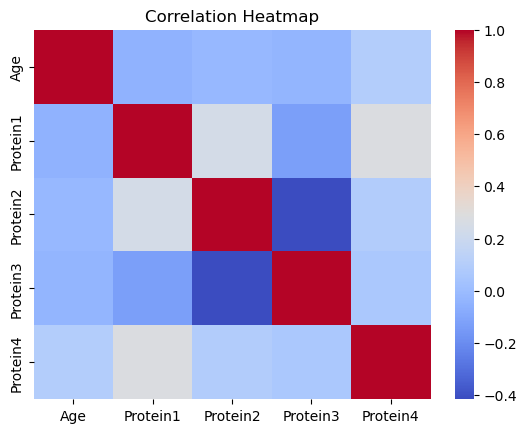

In [39]:
# correlation heatmap
plt.Figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True),cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [40]:
df_num

,Age,Protein1,Protein2,Protein3,Protein4
0,42.0,0.952560,2.15000,0.007972,-0.048340
1,54.0,-0.030172,1.38020,-0.498030,-0.507320
2,63.0,-0.523030,1.76400,-0.370190,0.010815
3,78.0,-0.876180,0.12943,-0.370380,0.132190
4,42.0,0.226110,1.74910,-0.543970,-0.390210
...,...,...,...,...,...
329,59.0,0.024598,1.40050,0.024751,0.280320
330,41.0,0.100120,-0.46547,0.472370,-0.523870
331,54.0,0.753820,1.64250,-0.332850,0.857860
332,74.0,0.972510,1.42680,-0.366570,-0.107820


In [41]:
y

0      1.0
1      0.0
2      1.0
3      1.0
4      1.0
      ... 
329    1.0
330    1.0
331    0.0
332    1.0
333    0.0
Name: Patient_Status, Length: 334, dtype: float64

In [ ]:
# split
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,y,test_size=0.2,random_state=42
)

In [ ]:
# scaling
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.fit_transform(x_test)

In [45]:
print(x_train.shape)
print(y_train.shape)

(267, 478)
(267,)


In [46]:
x_train

array([[-1.5792299 , -0.46582534, -0.82372499, ..., -0.06131393,
        -0.06131393, -0.06131393],
       [ 1.41722071, -0.52299394, -1.22377858, ..., -0.06131393,
        -0.06131393, -0.06131393],
       [-0.8877413 , -0.31767834,  1.17716025, ..., -0.06131393,
        -0.06131393, -0.06131393],
       ...,
       [-0.73407716,  0.1580079 ,  0.43303633, ..., -0.06131393,
        -0.06131393, -0.06131393],
       [ 1.57088484, -0.87071134, -1.39828293, ..., -0.06131393,
        -0.06131393, -0.06131393],
       [ 0.03424351,  0.7202389 ,  0.28746639, ..., -0.06131393,
        -0.06131393, -0.06131393]])

In [47]:
y_train

224    1.0
78     1.0
295    0.0
17     0.0
24     1.0
      ... 
188    NaN
71     1.0
106    1.0
270    1.0
102    1.0
Name: Patient_Status, Length: 267, dtype: float64

In [48]:
x_test

array([[ 1.25751155,  0.15665026, -1.44833936, ...,  0.        ,
         0.        ,  0.        ],
       [-0.65371583, -0.17139661,  0.52110563, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.46116681, -1.88589067,  0.11230304, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [-0.09627451,  0.49941365, -1.93234244, ...,  0.        ,
         0.        ,  0.        ],
       [-1.45006057,  0.34712605,  0.28431232, ...,  0.        ,
         0.        ,  0.        ],
       [-0.33517794, -0.90162936, -0.76368939, ...,  0.        ,
         0.        ,  0.        ]])

In [49]:
y_test

25     1.0
309    1.0
73     1.0
195    1.0
57     1.0
      ... 
280    1.0
3      1.0
77     1.0
311    1.0
60     NaN
Name: Patient_Status, Length: 67, dtype: float64

In [50]:
print(type(x_train))
print(type(y_train))

<class 'numpy.ndarray'>
<class 'pandas.core.series.Series'>


In [52]:
print("Missing values:\n",pd.DataFrame(x_train).isnull().sum().sum())

print("Data types:\n",pd.DataFrame(x_train).dtypes.unique())

Missing values:
 0
Data types:
 [dtype('float64')]


In [53]:
print(df['Patient_Status'].unique())

['Alive' 'Dead' nan]


In [54]:
# removes spaces
df['Patient_Status'] = df['Patient_Status'].str.strip()

# fix case
df['Patient_Status'] = df['Patient_Status'].str.capitalize()

In [55]:
# clean target column properly
df['Patient_Status'] = df['Patient_Status'].astype(str)
df['Patient_Status'] = df['Patient_Status'].str.strip()
df['Patient_Status'] = df['Patient_Status'].str.lower()

# check unique values
print("Before mapping:",df['Patient_Status'].unique())

# remove invalid rows 
valid_index = y.notnull()
y = y[valid_index]
x = df.loc[valid_index].drop('Patient_Status',axis=1)

# final check
print("NAN in y after cleaning:",y.isnull().sum())
print("Final shape:",x.shape,y.shape)

Before mapping: ['alive' 'dead' 'nan']
NAN in y after cleaning: 0
Final shape: (321, 14) (321,)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

models = {
    "logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier()
}

for name, model in models.items():
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    print(name)
    print("Accuracy:", accuracy_score(y_test,y_pred))
    print("-"*30)

logistic Regression
Accuracy: 0.7846153846153846
------------------------------
Decision Tree
Accuracy: 0.6615384615384615
------------------------------
Random Forest
Accuracy: 0.7692307692307693
------------------------------
KNN
Accuracy: 0.7692307692307693
------------------------------


In [65]:
training_score = []
testing_score = []
 
k_values = range(1,15)

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(x_train,y_train)

    # training accuracy
    train_pred = knn.predict(x_train)
    training_score.append(accuracy_score(y_train,train_pred))

    # testing accuracy
    test_pred = knn.predict(x_test)
    testing_score.append(accuracy_score(y_test,test_pred))

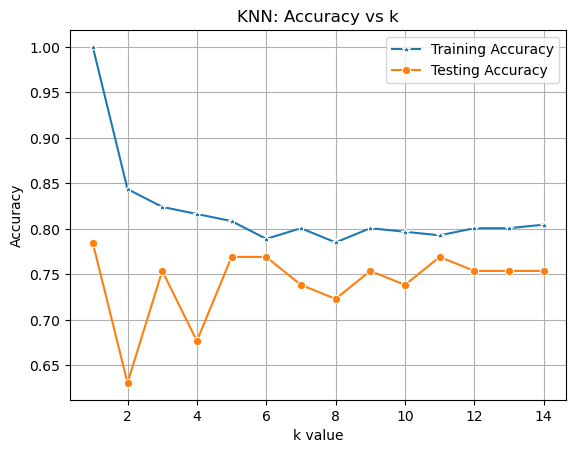

In [66]:
plt.Figure(figsize=(12,5))

sns.lineplot(x=k_values,y=training_score,marker='*',label='Training Accuracy')
sns.lineplot(x=k_values,y=testing_score,marker='o',label='Testing Accuracy')

plt.xlabel("k value")
plt.ylabel("Accuracy")
plt.title("KNN: Accuracy vs k")
plt.legend()
plt.grid(True)

plt.show()

In [67]:
best_k = k_values[testing_score.index(max(testing_score))]
print("Best k:",best_k)

Best k: 1


In [68]:
knn.score(x_test,y_test)

0.7538461538461538

In [69]:
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
yhat = knn.predict(x_test)
accuracy_score(y_test,yhat)

0.7538461538461538

In [70]:
confusion_matrix(y_test,yhat)

array([[ 0, 15],
       [ 1, 49]], dtype=int64)

<Axes: >

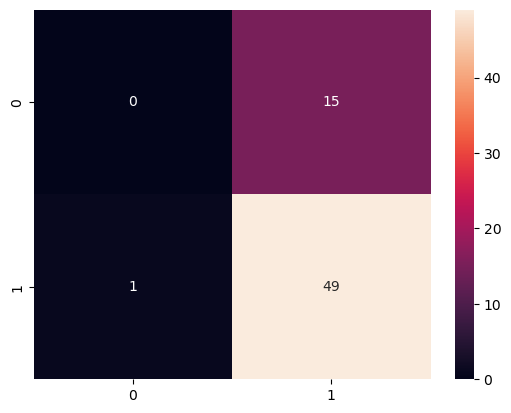

In [71]:
sns.heatmap(confusion_matrix(y_test,yhat),annot=True)

In [72]:
len(y_test)

65

In [73]:
print(classification_report(y_test,yhat))

              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00        15
         1.0       0.77      0.98      0.86        50

    accuracy                           0.75        65
   macro avg       0.38      0.49      0.43        65
weighted avg       0.59      0.75      0.66        65



In [99]:
# Define models (correct variable name)
models = {
    "KNN": KNeighborsClassifier(n_neighbors=best_k),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}

best_model = None
best_accuracy = 0

# Lists for graph
model_names = []
accuracies = []

# Loop
for name, model in models.items():
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)

    acc = accuracy_score(y_test, y_pred)

    print("\n", name)
    print("Accuracy:", acc)
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))

    # Store values
    model_names.append(name)
    accuracies.append(acc)

    # Best model
    if acc > best_accuracy:
        best_accuracy = acc
        best_model = model

print("\nBest Model Selected:", best_model)


 KNN
Accuracy: 0.7846153846153846
[[ 5 10]
 [ 4 46]]
              precision    recall  f1-score   support

         0.0       0.56      0.33      0.42        15
         1.0       0.82      0.92      0.87        50

    accuracy                           0.78        65
   macro avg       0.69      0.63      0.64        65
weighted avg       0.76      0.78      0.76        65


 Logistic Regression
Accuracy: 0.7846153846153846
[[ 1 14]
 [ 0 50]]
              precision    recall  f1-score   support

         0.0       1.00      0.07      0.12        15
         1.0       0.78      1.00      0.88        50

    accuracy                           0.78        65
   macro avg       0.89      0.53      0.50        65
weighted avg       0.83      0.78      0.70        65


 Decision Tree
Accuracy: 0.676923076923077
[[ 2 13]
 [ 8 42]]
              precision    recall  f1-score   support

         0.0       0.20      0.13      0.16        15
         1.0       0.76      0.84      0.80       

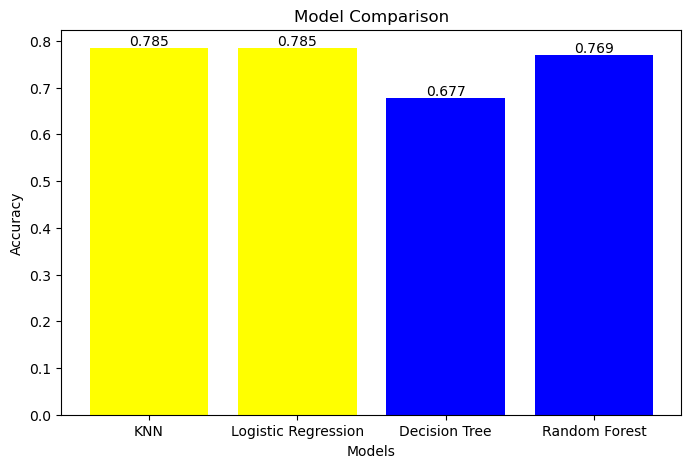

In [100]:
best_acc = max(accuracies)

colors = ["blue" if acc < best_acc else "yellow" for acc in accuracies]

plt.figure(figsize=(8,5))
bars = plt.bar(model_names, accuracies, color=colors)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval,
             round(yval,3), ha='center', va='bottom')

plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.show()

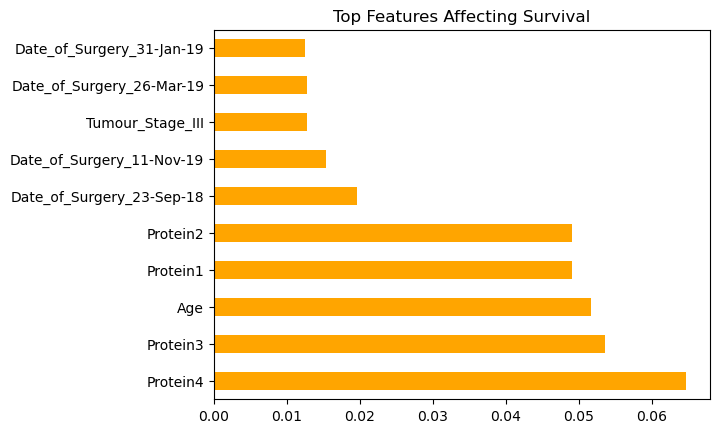

In [103]:
rf = RandomForestClassifier()
rf.fit(x_train,y_train)

importances = pd.Series(rf.feature_importances_,index=x.columns)
importances.nlargest(10).plot(kind='barh', color='orange')
plt.title("Top Features Affecting Survival")
plt.show()

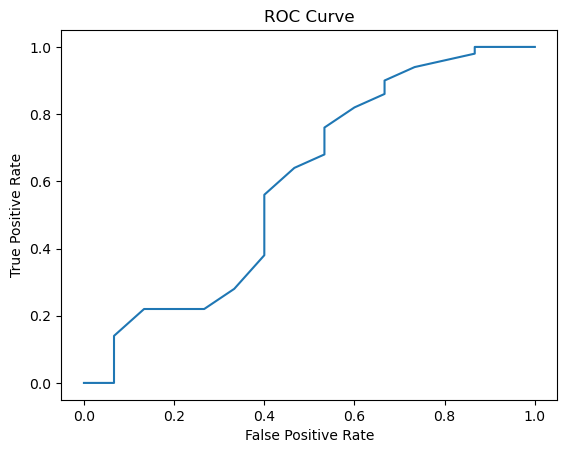

In [88]:
# roc curve
from sklearn.metrics import roc_curve

y_prob = rf.predict_proba(x_test)[:,1]
fpr,tpr,_ = roc_curve(y_test,y_prob)

plt.plot(fpr,tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()